In [ ]:
!nvidia-smi

Thu Apr  9 12:00:49 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   39C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
!pip install kaggle

# Upload kaggle.json
from google.colab import files
files.upload()

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Download dataset
!kaggle datasets download -d sabidrahman/pothole-cracks-and-openmanhole

# Unzip
!unzip pothole-cracks-and-openmanhole.zip -d dataset

Streaming output truncated to the last 5000 lines.
  inflating: dataset/dataset/dataset/train/images/1098_aug_vertical_flip.jpg  
  inflating: dataset/dataset/dataset/train/images/1099.jpg  
  inflating: dataset/dataset/dataset/train/images/1099_aug_brightness_contrast.jpg  
  inflating: dataset/dataset/dataset/train/images/1099_aug_flip.jpg  
  inflating: dataset/dataset/dataset/train/images/1099_aug_rotate.jpg  
  inflating: dataset/dataset/dataset/train/images/1099_aug_vertical_flip.jpg  
  inflating: dataset/dataset/dataset/train/images/109_aug_grayscale.jpg  
  inflating: dataset/dataset/dataset/train/images/109_augmented.jpg  
  inflating: dataset/dataset/dataset/train/images/10_aug_grayscale.jpg  
  inflating: dataset/dataset/dataset/train/images/10_augmented.jpg  
  inflating: dataset/dataset/dataset/train/images/11.jpg  
  inflating: dataset/dataset/dataset/train/images/110.jpg  
  inflating: dataset/dataset/dataset/train/images/1100.jpg  
  inflating: dataset/dataset/dataset/

In [ ]:
!ls /content/dataset -R

/content/dataset:
dataset			  train_annotations1.json
potholedetectionpc.ipynb  valid_annotations1.json

/content/dataset/dataset:
dataset

/content/dataset/dataset/dataset:
classes  desktop.ini  test  train  valid

/content/dataset/dataset/dataset/classes:
cracks	desktop.ini  good_road	open_manhole  pothole

/content/dataset/dataset/dataset/classes/cracks:
augmented  desktop.ini	images	labels

/content/dataset/dataset/dataset/classes/cracks/augmented:
desktop.ini  images  labels

/content/dataset/dataset/dataset/classes/cracks/augmented/images:
desktop.ini

/content/dataset/dataset/dataset/classes/cracks/augmented/labels:
desktop.ini  txt

/content/dataset/dataset/dataset/classes/cracks/augmented/labels/txt:
desktop.ini

/content/dataset/dataset/dataset/classes/cracks/images:
501.jpg  522.jpg  543.jpg  564.jpg  585.jpg  606.jpg  627.jpg  648.jpg
502.jpg  523.jpg  544.jpg  565.jpg  586.jpg  607.jpg  628.jpg  649.jpg
503.jpg  524.jpg  545.jpg  566.jpg  587.jpg  608.jpg  629.jpg  650.jpg

In [ ]:
import os

for root, dirs, files in os.walk("/content"):
    if "images" in root:
        print(root)

/content/dataset/dataset/dataset/test/images
/content/dataset/dataset/dataset/train/images
/content/dataset/dataset/dataset/valid/images
/content/dataset/dataset/dataset/classes/open_manhole/augmented/images
/content/dataset/dataset/dataset/classes/open_manhole/images
/content/dataset/dataset/dataset/classes/pothole/valid_pothole_images
/content/dataset/dataset/dataset/classes/pothole/augmented/images
/content/dataset/dataset/dataset/classes/pothole/images
/content/dataset/dataset/dataset/classes/cracks/augmented/images
/content/dataset/dataset/dataset/classes/cracks/images
/content/dataset/dataset/dataset/classes/good_road/images


In [ ]:
import os

base_path = "/content/dataset"

for root, dirs, files in os.walk(base_path):
    if root.endswith("train/images"):
        image_dir = root
        images = files
        break

print("Using path:", image_dir)
print("Total images:", len(images))

Using path: /content/dataset/dataset/dataset/train/images
Total images: 2237


In [ ]:
import cv2

test_img = cv2.imread(f"{image_dir}/{images[0]}")
print(test_img.shape)

(408, 612, 3)


In [ ]:
img_path = f"{image_dir}/{images[0]}"
print(img_path)

/content/dataset/dataset/dataset/train/images/1043_aug_rotate.jpg


In [ ]:
import os
import cv2
import re

image_dir = "/content/dataset/dataset/dataset/train/images"
def natural_sort_key(s):
    return [int(text) if text.isdigit() else text.lower()
            for text in re.split('([0-9]+)', s)]

images = sorted(os.listdir(image_dir), key=natural_sort_key)

raw_dir = "/content/raw"
os.makedirs(raw_dir, exist_ok=True)

valid_ext = ('.jpg', '.jpeg', '.png')

count = 0

for img_name in images:

    if not img_name.lower().endswith(valid_ext):
        continue

    img_path = f"{image_dir}/{img_name}"
    raw_path = f"{raw_dir}/{count}.rgb"

    img = cv2.imread(img_path)

    if img is None:
        print("Skipping bad file:", img_name)
        continue

    img = cv2.resize(img, (256, 256))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    img.tofile(raw_path)

    count += 1

print("Total RAW files:", count)

Total RAW files: 2236


CUDA CODE

In [ ]:
%%writefile pothole.cu
#include <stdio.h>
#include <cuda_runtime.h>
#include <math.h>
#include <chrono>

using namespace std::chrono;

__global__ void process(cudaTextureObject_t texObj, unsigned char* output, int width, int height)
{
    int x = blockIdx.x * blockDim.x + threadIdx.x;
    int y = blockIdx.y * blockDim.y + threadIdx.y;

    if (x <= 1 || y <= 1 || x >= width-2 || y >= height-2) return;

    int kernel[3][3] = {
        {1,2,1},
        {2,4,2},
        {1,2,1}
    };

    float blur = 0;
    float sum = 0;

    for(int i=-1;i<=1;i++){
        for(int j=-1;j<=1;j++){

            int xx = x + i;
            int yy = y + j;

            float r = tex2D<unsigned char>(texObj, xx*3, yy);
            float g = tex2D<unsigned char>(texObj, xx*3+1, yy);
            float b = tex2D<unsigned char>(texObj, xx*3+2, yy);

            float gray = 0.299f*r + 0.587f*g + 0.114f*b;

            blur += gray * kernel[i+1][j+1];
            sum += kernel[i+1][j+1];
        }
    }

    blur /= sum;

    int Gx[3][3] = {
        {-1,0,1},
        {-2,0,2},
        {-1,0,1}
    };

    int Gy[3][3] = {
        {-1,-2,-1},
        {0,0,0},
        {1,2,1}
    };

    float gx = 0, gy = 0;

    for(int i=-1;i<=1;i++){
        for(int j=-1;j<=1;j++){

            int xx = x + i;
            int yy = y + j;

            float r = tex2D<unsigned char>(texObj, xx*3, yy);
            float g = tex2D<unsigned char>(texObj, xx*3+1, yy);
            float b = tex2D<unsigned char>(texObj, xx*3+2, yy);

            float gray = 0.299f*r + 0.587f*g + 0.114f*b;

            gx += gray * Gx[i+1][j+1];
            gy += gray * Gy[i+1][j+1];
        }
    }

    float edge = sqrtf(gx*gx + gy*gy);

    output[y * width + x] = (edge > 120) ? 255 : 0;
}

int main()
{

    int width = 256, height = 256;
    size_t size = width * height * 3;

    FILE* f = fopen("input.rgb", "rb");
    if (!f) {
        printf("Error opening input file\\n");
        return -1;
    }

    unsigned char* h_input = (unsigned char*)malloc(size);
    fread(h_input, 1, size, f);
    fclose(f);

    unsigned char *d_input, *d_output;
    cudaMalloc(&d_input, size);
    cudaMalloc(&d_output, width*height);

    cudaMemcpy(d_input, h_input, size, cudaMemcpyHostToDevice);

    cudaResourceDesc resDesc = {};
    resDesc.resType = cudaResourceTypePitch2D;
    resDesc.res.pitch2D.devPtr = d_input;
    resDesc.res.pitch2D.width = width * 3;
    resDesc.res.pitch2D.height = height;
    resDesc.res.pitch2D.pitchInBytes = width * 3;
    resDesc.res.pitch2D.desc = cudaCreateChannelDesc<unsigned char>();

    cudaTextureDesc texDesc = {};
    texDesc.readMode = cudaReadModeElementType;
    texDesc.normalizedCoords = 0;

    cudaTextureObject_t texObj = 0;
    cudaCreateTextureObject(&texObj, &resDesc, &texDesc, NULL);

    dim3 block(16,16);
    dim3 grid((width+15)/16, (height+15)/16);

    process<<<grid, block>>>(texObj, d_output, width, height);
    cudaDeviceSynchronize();

    unsigned char* h_output = (unsigned char*)malloc(width*height);
    cudaMemcpy(h_output, d_output, width*height, cudaMemcpyDeviceToHost);

    FILE* out = fopen("output.raw", "wb");
    fwrite(h_output, 1, width*height, out);
    fclose(out);

    cudaDestroyTextureObject(texObj);
    cudaFree(d_input);
    cudaFree(d_output);

    return 0;
}

Overwriting pothole.cu


In [ ]:
!nvcc pothole.cu -o pothole

nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).


In [ ]:
import cv2
import os

raw_dir = "/content/raw"
os.makedirs(raw_dir, exist_ok=True)

for i, img_name in enumerate(images[:50]):
    img = cv2.imread(f"{image_dir}/{img_name}")
    img = cv2.resize(img, (256,256))
    img.tofile(f"{raw_dir}/{i}.rgb")

In [ ]:
import os
import subprocess

output_dir = "/content/output"
os.makedirs(output_dir, exist_ok=True)

for i in range(20):   # change count if needed
    os.system(f"cp /content/raw/{i}.rgb input.rgb")
    subprocess.run(["./pothole"])
    os.rename("output.raw", f"{output_dir}/{i}.raw")

print("GPU processing done")

GPU processing done


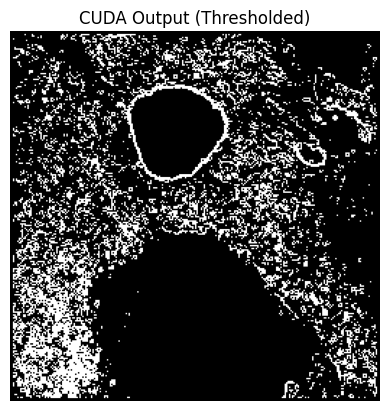

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

img = np.fromfile("/content/output/3.raw", dtype=np.uint8).reshape(256,256)

plt.imshow(img, cmap='gray')
plt.title("CUDA Output (Thresholded)")
plt.axis('off')
plt.show()

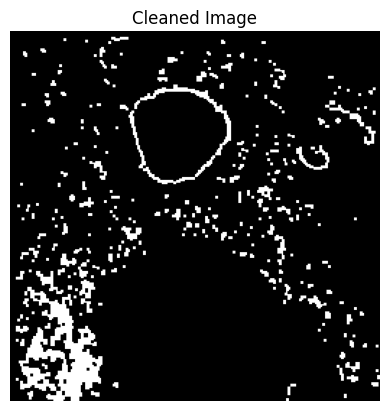

In [ ]:
kernel = np.ones((2,2), np.uint8)

clean = cv2.morphologyEx(img, cv2.MORPH_OPEN, kernel)
clean = cv2.morphologyEx(clean, cv2.MORPH_CLOSE, kernel)

plt.imshow(clean, cmap='gray')
plt.title("Cleaned Image")
plt.axis('off')
plt.show()

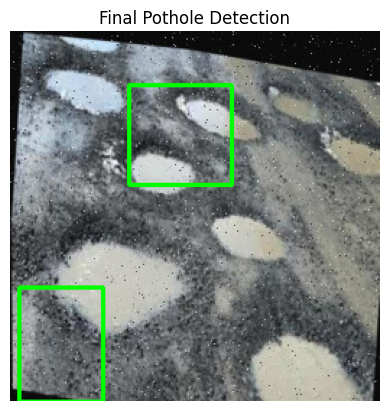

In [ ]:
contours, _ = cv2.findContours(clean, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
orig = cv2.imread(f"{image_dir}/{images[3]}")
orig = cv2.resize(orig, (256,256))

for cnt in contours:
    area = cv2.contourArea(cnt)

    if area > 150:
        x,y,w,h = cv2.boundingRect(cnt)
        cv2.rectangle(orig, (x,y), (x+w,y+h), (0,255,0), 2)

plt.imshow(cv2.cvtColor(orig, cv2.COLOR_BGR2RGB))
plt.title("Final Pothole Detection")
plt.axis('off')
plt.show()

MULTIPLE SAMPLE IMAGES

Processing Image 12


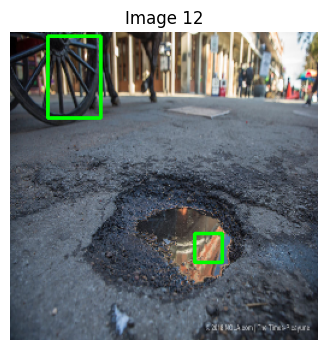

Processing Image 13


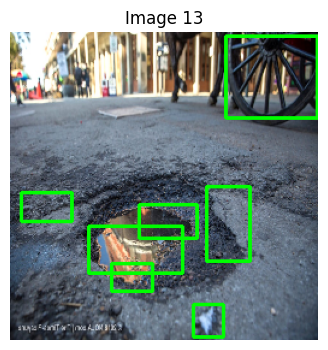

Processing Image 14


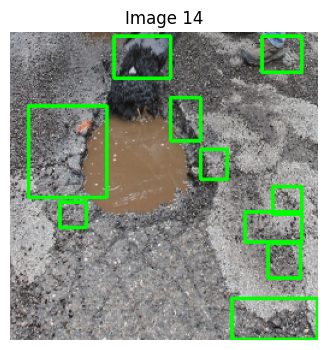

Processing Image 15


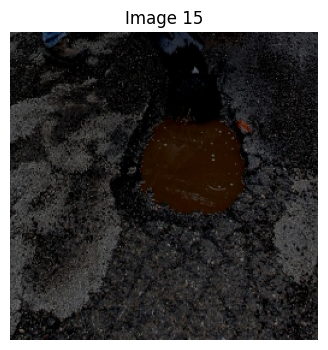

Processing Image 16


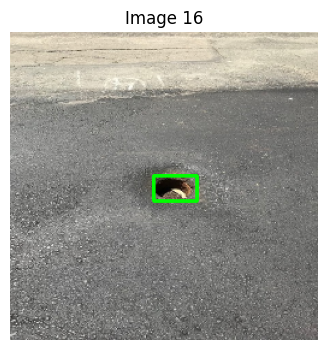

Processing Image 17


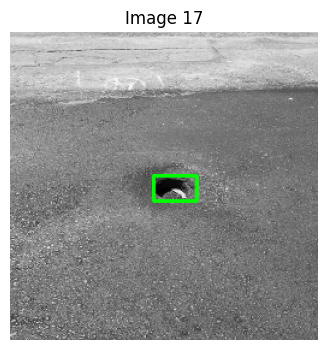

Processing Image 18


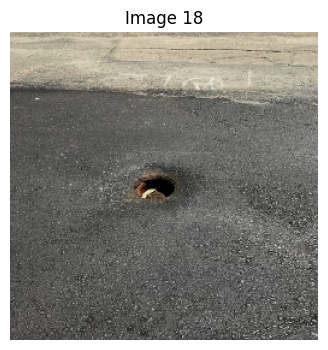

Processing Image 19


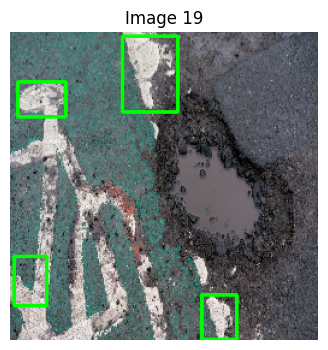

Processing Image 20


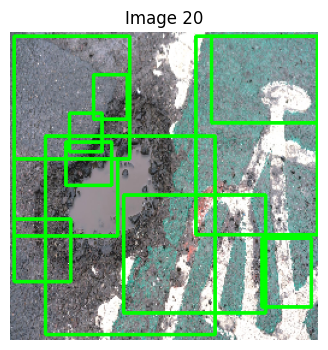

Processing Image 21


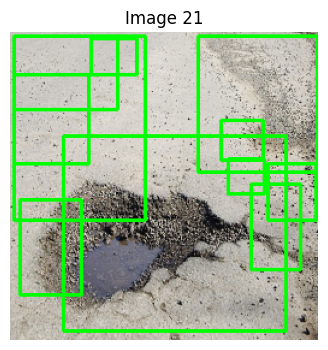

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

num_samples = 6   # change to 10 if needed

for i in range(12,22,1):

    print(f"Processing Image {i}")

    # Load CUDA output
    img = np.fromfile(f"/content/output/{i}.raw", dtype=np.uint8).reshape(256,256)

    # Morphology
    kernel = np.ones((2,2), np.uint8)
    clean = cv2.morphologyEx(img, cv2.MORPH_OPEN, kernel)

    # Contours
    contours, _ = cv2.findContours(clean, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # Load original image
    orig = cv2.imread(f"{image_dir}/{images[i]}")
    orig = cv2.resize(orig, (256,256))

    # Draw boxes
    for cnt in contours:
        area = cv2.contourArea(cnt)
        x,y,w,h = cv2.boundingRect(cnt)

        aspect_ratio = w / float(h)

        if area > 100 and 0.5 < aspect_ratio < 2.5 and w > 20 and h > 20:
            cv2.rectangle(orig, (x,y), (x+w,y+h), (0,255,0), 2)

    # Show result
    plt.figure(figsize=(4,4))
    plt.imshow(cv2.cvtColor(orig, cv2.COLOR_BGR2RGB))
    plt.title(f"Image {i}")
    plt.axis('off')
    plt.show()

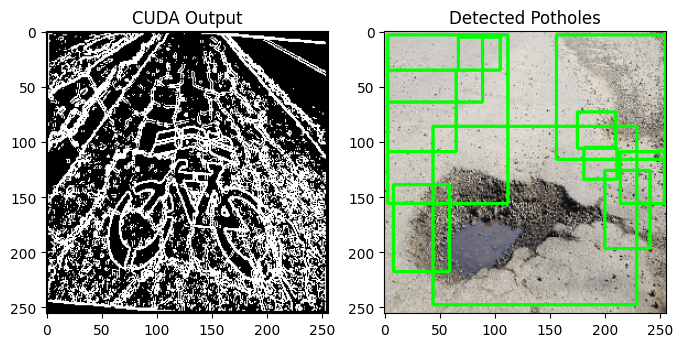

In [ ]:
plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(img, cmap='gray')
plt.title("CUDA Output")

plt.subplot(1,2,2)
plt.imshow(cv2.cvtColor(orig, cv2.COLOR_BGR2RGB))
plt.title("Detected Potholes")

plt.show()

In [ ]:
from google.colab import files
files.download("pothole.cu")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
files.download("input.rgb")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

CPU

In [ ]:
import cv2
import numpy as np

def process_cpu(image):

    # Grayscale
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Gaussian Blur
    blur = cv2.GaussianBlur(gray, (3,3), 0)

    # Sobel
    sobelx = cv2.Sobel(blur, cv2.CV_64F, 1, 0, ksize=3)
    sobely = cv2.Sobel(blur, cv2.CV_64F, 0, 1, ksize=3)

    edge = np.sqrt(sobelx**2 + sobely**2)

    # Threshold (same as CUDA ≈120)
    output = (edge > 120).astype(np.uint8) * 255

    return output

In [ ]:
image = cv2.imread(f"{image_dir}/{images[0]}")
image = cv2.resize(image, (256,256))

In [ ]:
import time

start = time.time()

out = process_cpu(image)

end = time.time()

print("CPU Time:", end - start)

CPU Time: 0.012689352035522461
